# QIQ 2024 full year: QC, REST2 clear-sky, and four separation models
# QIQ 2024 全年：QC、REST2 晴空与四种分离模型

This tutorial **loops over twelve** BSRN station-to-archive files (`qiq0124.dat.gz` … `qiq1224.dat.gz`), concatenates them, runs **`run_qc`**, adds **REST2** clear-sky columns via **`add_clearsky_columns`** (MERRA-2 inputs from Hugging Face), then runs **Erbs**, **BRL**, **Engerer2**, and **Yang4** separation and plots **`k` vs `k_t`** with **`plot_k_vs_kt`**.

本教程**循环读取 12 个**月文件并拼接，执行 **`run_qc`**，用 **`add_clearsky_columns`**（**REST2**，MERRA-2 来自 Hugging Face）加入晴空列，再运行 **Erbs / BRL / Engerer2 / Yang4** 分离，并用 **`plot_k_vs_kt`** 绘制 **散射分数 `k` 与晴朗指数 `k_t`**。


## Prerequisites / 前置条件

- All **12** files under `data/QIQ/` for 2024 (see `data/download_qiq_2024.py` or tutorial 1).
- **Network** access for **REST2** (first run downloads MERRA-2 parquet per month from Hugging Face).
- **`pip install 'bsrn[viz]'`** (plotnine, matplotlib) for the figure.
- Set **`REPO_ROOT`** in the next cell to your local clone (absolute path).

- `data/QIQ/` 下需有 **12** 个月 `qiqMM24.dat.gz`。
- **REST2** 首次运行需联网从 Hugging Face 拉取 MERRA-2。
- 安装 **`bsrn[viz]`**；在下一格将 **`REPO_ROOT`** 设为本机仓库**绝对路径**。


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from bsrn.constants import BSRN_STATIONS
from bsrn.io.reader import read_station_to_archive
from bsrn.modeling.clear_sky import add_clearsky_columns
from bsrn.modeling.separation import (
    brl_separation,
    engerer2_separation,
    erbs_separation,
    yang4_separation,
)
from bsrn.qc.wrapper import run_qc
from bsrn.visualization.separation import plot_k_vs_kt

REPO_ROOT = Path("/Volumes/Macintosh Research/Data/bsrn-qc")
DATA_DIR = REPO_ROOT / "data" / "QIQ"
STATION_CODE = "QIQ"
YEAR_SUFFIX = "24"  # 2024 / 2024 年 → qiqMM24.dat.gz

meta = BSRN_STATIONS[STATION_CODE]
lat, lon, elev = meta["lat"], meta["lon"], meta["elev"]

print("REPO_ROOT:", REPO_ROOT)
print("DATA_DIR: ", DATA_DIR)
print("Station:  ", STATION_CODE, lat, lon, elev)


REPO_ROOT: /Volumes/Macintosh Research/Data/bsrn-qc
DATA_DIR:  /Volumes/Macintosh Research/Data/bsrn-qc/data/QIQ
Station:   QIQ 47.7957 124.4852 170.0


## 1. Load twelve monthly files / 读取十二个月文件

Skip any month that is missing on disk (with a warning).

若某月文件不存在则跳过并警告。


In [2]:
chunks: list[pd.DataFrame] = []
missing: list[str] = []

for month in range(1, 13):
    name = f"{STATION_CODE.lower()}{month:02d}{YEAR_SUFFIX}.dat.gz"
    path = DATA_DIR / name
    if not path.is_file():
        missing.append(name)
        continue
    sub = read_station_to_archive(str(path), logical_records="lr0100")
    if sub is None or sub.empty:
        missing.append(f"{name} (empty or read failed)")
        continue
    chunks.append(sub)
    print(f"Loaded {name}  rows={len(sub):,}")

if missing:
    print("WARNING — skipped:", ", ".join(missing))
if not chunks:
    raise FileNotFoundError(
        f"No monthly files found under {DATA_DIR}. "
        "Download QIQ 2024 archives first (e.g. data/download_qiq_2024.py)."
    )

df = pd.concat(chunks, axis=0)
df = df[~df.index.duplicated(keep="first")].sort_index()
print(f"\nConcatenated: {len(df):,} rows  {df.index.min()} … {df.index.max()} UTC")


Loaded qiq0124.dat.gz  rows=44,640
Loaded qiq0224.dat.gz  rows=41,760
Loaded qiq0324.dat.gz  rows=44,640
Loaded qiq0424.dat.gz  rows=43,200
Loaded qiq0524.dat.gz  rows=44,640
Loaded qiq0624.dat.gz  rows=43,200
Loaded qiq0724.dat.gz  rows=44,640
Loaded qiq0824.dat.gz  rows=44,640
Loaded qiq0924.dat.gz  rows=43,200
Loaded qiq1024.dat.gz  rows=44,640
Loaded qiq1124.dat.gz  rows=43,200
Loaded qiq1224.dat.gz  rows=44,640

Concatenated: 527,040 rows  2024-01-01 00:00:00+00:00 … 2024-12-31 23:59:00+00:00 UTC


## 2. Quality control + REST2 clear-sky / QC 与 REST2 晴空

**`run_qc`** adds `flag*` columns (same pipeline as tutorial 2). **`add_clearsky_columns`** with **`model='rest2'`** adds `ghi_clear`, `bni_clear`, `dhi_clear` using MERRA-2 (may take a few minutes the first time). After clear-sky, we **subset** the frame to rows with **all flags 0** (pass) and **solar zenith ≤ 85°** (exclude low-sun geometry).

**`run_qc`** 添加 `flag*` 列。**`add_clearsky_columns(..., model='rest2')`** 写入 REST2 晴空列（首次可能较慢）。晴空之后**只保留**所有 **`flag*` 均为 0**（通过）且**天顶角 ≤ 85°** 的行。


In [3]:
from bsrn.physics import geometry

run_qc(df, station_code=STATION_CODE)
print("QC flags:", [c for c in df.columns if c.startswith("flag")][:6], "...")

df = add_clearsky_columns(df, station_code=STATION_CODE, model="rest2")
print("REST2 columns added; ghi_clear sample:", float(df["ghi_clear"].iloc[len(df) // 2]))

n_before = len(df)
flag_cols = [c for c in df.columns if c.startswith("flag")]
qc_ok = (
    (df[flag_cols] == 0).all(axis=1)
    if flag_cols
    else pd.Series(True, index=df.index)
)
zenith = geometry.get_solar_position(df.index, lat, lon, elev)["zenith"]
sun_ok = zenith <= 85.0
df = df.loc[qc_ok & sun_ok]
print(f"Filtered {n_before:,} → {len(df):,} rows (all QC flags 0, zenith ≤ 85°)")


QC flags: ['flagPPLGHI', 'flagPPLBNI', 'flagPPLDHI', 'flagPPLLWD', 'flagERLGHI', 'flagERLBNI'] ...
Fetching MERRA-2 from Hugging Face: qiq/qiq0124_merra2.parquet
Fetching MERRA-2 from Hugging Face: qiq/qiq0224_merra2.parquet
Fetching MERRA-2 from Hugging Face: qiq/qiq0324_merra2.parquet
Fetching MERRA-2 from Hugging Face: qiq/qiq0424_merra2.parquet
Fetching MERRA-2 from Hugging Face: qiq/qiq0524_merra2.parquet
Fetching MERRA-2 from Hugging Face: qiq/qiq0624_merra2.parquet
Fetching MERRA-2 from Hugging Face: qiq/qiq0724_merra2.parquet
Fetching MERRA-2 from Hugging Face: qiq/qiq0824_merra2.parquet
Fetching MERRA-2 from Hugging Face: qiq/qiq0924_merra2.parquet
Fetching MERRA-2 from Hugging Face: qiq/qiq1024_merra2.parquet
Fetching MERRA-2 from Hugging Face: qiq/qiq1124_merra2.parquet
Fetching MERRA-2 from Hugging Face: qiq/qiq1224_merra2.parquet
REST2 columns added; ghi_clear sample: 560.3791024928188
Filtered 527,040 → 235,581 rows (all QC flags 0, zenith ≤ 85°)


## 3. Four separation models / 四种分离模型

Store model diffuse fraction **`k`** in columns for **`plot_k_vs_kt`**. Engerer2 uses **`averaging_period=1`** for 1-minute data.

将各模型的 **`k`** 写入列供作图；1 分钟数据 Engerer2 使用 **`averaging_period=1`**。


In [4]:
times = df.index
ghi = df["ghi"].to_numpy(dtype=float)

df["k_erbs"] = erbs_separation(times, ghi, lat, lon, elev=elev)["k"]
df["k_brl"] = brl_separation(times, ghi, lat, lon)["k"]
df["k_engerer2"] = engerer2_separation(
    times, ghi, lat, lon, df["ghi_clear"].to_numpy(dtype=float), averaging_period=1
)["k"]
df["k_yang4"] = yang4_separation(
    times, ghi, lat, lon, df["ghi_clear"].to_numpy(dtype=float)
)["k"]

print("k columns OK; non-NaN counts:")
for c in ("k_erbs", "k_brl", "k_engerer2", "k_yang4"):
    print(f"  {c}: {df[c].notna().sum():,}")


k columns OK; non-NaN counts:
  k_erbs: 235,581
  k_brl: 235,581
  k_engerer2: 235,581
  k_yang4: 235,581


## 4. `k` vs `k_t` plot / k–k_t 图

Faceted density plot (measured gray + model viridis), **160 mm** wide per project style.

分面密度图（实测灰 + 模型 viridis），**160 mm** 栏宽。


Saved: /Volumes/Macintosh Research/Data/bsrn-qc/_tmp_QIQ_2024_separation_k_kt.pdf


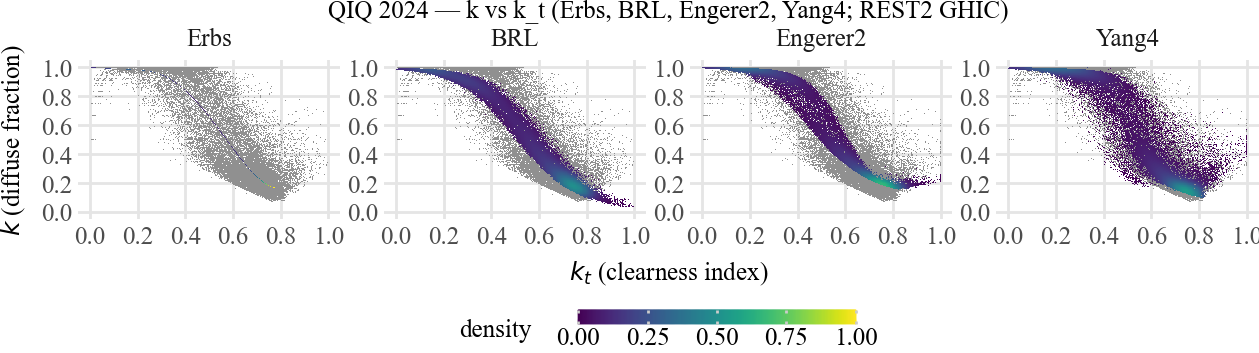

In [5]:
k_mod_cols = {
    "erbs": "k_erbs",
    "brl": "k_brl",
    "engerer2": "k_engerer2",
    "yang4": "k_yang4",
}

title = f"{STATION_CODE} 2024 — k vs k_t (Erbs, BRL, Engerer2, Yang4; REST2 GHIC)"
out_pdf = REPO_ROOT / f"_tmp_{STATION_CODE}_2024_separation_k_kt.pdf"

p = plot_k_vs_kt(
    df,
    models=("erbs", "brl", "engerer2", "yang4"),
    lat=lat,
    lon=lon,
    ghi_col="ghi",
    dhi_col="dhi",
    k_mod_cols=k_mod_cols,
    title=title,
    output_file=str(out_pdf),
)
print("Saved:", out_pdf)
p
